In [2]:
 import os
os.environ['TF_ENABLE_LAYOUT_OPTIMIZATION'] = '0'

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import warnings 
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Reshape, Bidirectional, LSTM, Dense, Activation, BatchNormalization, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers as layers
from sklearn.model_selection import train_test_split

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Concatenate,Flatten
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
# Paths for datasets
sentences_txt_path = "/kaggle/input/dataset/metadata/sentences.txt"
sentences_folder_path = "/kaggle/input/dataset/dataset"

In [9]:
# Load and process dataset
dataset, vocab, max_len = [], set(), 0


with open(sentences_txt_path, 'r') as f:
    rows = f.readlines()

for row in rows:
    if row.startswith('#'): #ignoring the comments
        continue

    columns = row.strip().split(' ') # splitting the text by spaces
    status = columns[2] # ok or err

    if status == 'ok':
        file_name = columns[0] + '.png' # image address
        label = columns[-1].replace('|',' ') # line text

        rel_path = os.path.join(sentences_folder_path, file_name)
        if os.path.exists(rel_path):
            dataset.append([rel_path, label])
            max_len = max(max_len, len(label))

max_text_length = max_len

In [10]:
data = pd.DataFrame(dataset, columns = ['path', 'label'])
data.head()

,path,label
0,/kaggle/input/dataset/dataset/a01-000u-s00-00.png,A MOVE to stop Mr. Gaitskell from
1,/kaggle/input/dataset/dataset/a01-000u-s00-01.png,nominating any more Labour life Peers
2,/kaggle/input/dataset/dataset/a01-000u-s00-02.png,is to be made at a meeting of Labour
3,/kaggle/input/dataset/dataset/a01-000u-s01-01.png,put down a resolution on the subject
4,/kaggle/input/dataset/dataset/a01-000u-s01-03.png,P for Manchester Exchange .


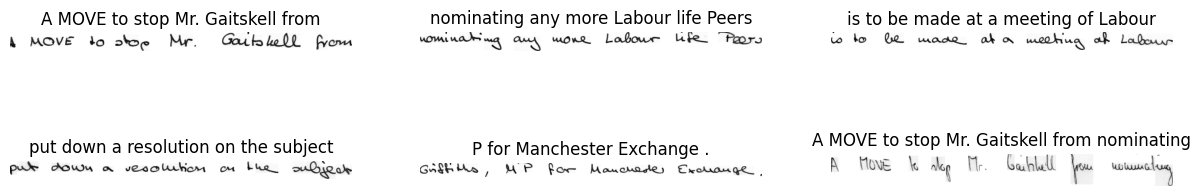

In [11]:
plt.figure(figsize=(15, 10))

for i in range(6):
    ax = plt.subplot(2, 3, i+1)
    img_dir = data.loc[i, 'path']
    image = cv2.imread(img_dir, cv2.IMREAD_GRAYSCALE)
    plt.imshow(image, cmap = 'gray')
    plt.title(data.loc[i, 'label'], fontsize=12)
    plt.axis('off')

plt.subplots_adjust(wspace=0.2, hspace=-0.8)

In [12]:
print("Number of NaNs in train set : ", data['label'].isnull().sum())

Number of NaNs in train set :  0


In [13]:
data.dropna(axis=0, inplace=True)
data['label'] = data['label'].str.upper()
data.reset_index(inplace = True, drop=True) 
len(data)

14083

In [15]:
train_y_labels_max=0
train_y_labels_sum=0
train_y_labels_count_freq={}
for i in range(len(data)):
    freq=len(data.loc[i,'label'])
    if freq in train_y_labels_count_freq:
        train_y_labels_count_freq[freq]=train_y_labels_count_freq[freq]+1
    else:
        train_y_labels_count_freq[freq]=1
    if freq>train_y_labels_max:
        train_y_labels_max=freq
    train_y_labels_sum = train_y_labels_sum+freq

print('max len:', train_y_labels_max)
print('avg len:', train_y_labels_sum/len(data))


max len: 93
avg len: 34.38251792941845


<BarContainer object of 79 artists>

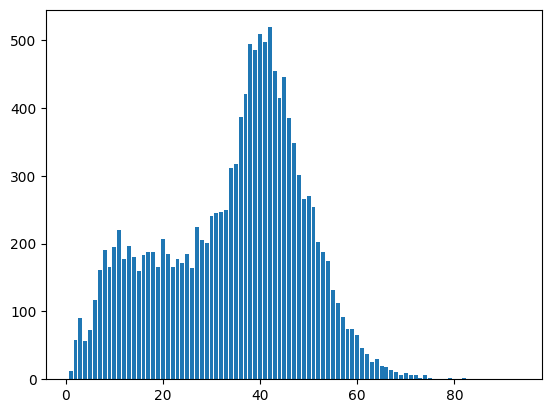

In [16]:
plt.bar(list(train_y_labels_count_freq.keys()),list(train_y_labels_count_freq.values()))

In [17]:
def augment_image(image):
    if np.random.rand() < 0.7:
        kernel_size = tuple(np.random.randint(3, 6, 2) * 2 + 1)  
        # kernel_size = tuple(np.random.randint(3, 12, 2) * 2 + 1)  
        image = cv2.GaussianBlur(image, kernel_size, 0)

    # Random Brightness Adjustment
    if np.random.rand() < 0.7:
        brightness_factor = np.random.uniform(0.8, 1.1)
        image = np.clip(image * brightness_factor, 0, 255).astype(np.uint8)

    # Random Contrast Adjustment
    if np.random.rand() < 0.7:
        contrast_factor = np.random.uniform(0.3, 1.3)
        image = np.clip((image - 127.5) * contrast_factor + 127.5, 0, 255).astype(np.uint8)

    # Random Saturation Adjustment
    if np.random.rand() < 0.7:
        saturation_factor = np.random.uniform(0.3, 1.3)
        hsv_image = cv2.cvtColor(cv2.cvtColor(image, cv2.COLOR_GRAY2BGR), cv2.COLOR_BGR2HSV)
        hsv_image[..., 1] = np.clip(hsv_image[..., 1] * saturation_factor, 0, 255)
        image = cv2.cvtColor(hsv_image, cv2.COLOR_HSV2BGR)[:, :, 2]

    rows, cols = image.shape
    shear_angle_x = np.random.uniform(-0.8, 0.8)
    shear_matrix_x = np.float32([[1, shear_angle_x, 0], [0, 1, 0]])
    sheared_image = cv2.warpAffine(image.copy(), shear_matrix_x, (cols, rows))

    return sheared_image


In [18]:
def resize_or_pad_image(image, target_height=64, target_width=512):
    image = cv2.resize(image, (target_width, target_height))
    return image

def preprocess(img):
    (h, w) = img.shape    
    final_image = resize_or_pad_image(img)
    return cv2.rotate(final_image, cv2.ROTATE_90_CLOCKWISE)

def preprocess1(img):
    (h, w) = img.shape    
    final_image = resize_or_pad_image(img)
    return augment_image(final_image)

In [19]:
# Load the image
for i in range(1,10):
    image = cv2.imread(data.loc[i,'path'])
    image = resize_or_pad_image(image)
    image_shape = image.shape

    print("Shape of the image:", image_shape)

Shape of the image: (64, 512, 3)
Shape of the image: (64, 512, 3)
Shape of the image: (64, 512, 3)
Shape of the image: (64, 512, 3)
Shape of the image: (64, 512, 3)
Shape of the image: (64, 512, 3)
Shape of the image: (64, 512, 3)
Shape of the image: (64, 512, 3)
Shape of the image: (64, 512, 3)


In [20]:
img_paths = list(data.iloc[0:3,0])
img_paths

['/kaggle/input/dataset/dataset/a01-000u-s00-00.png',
 '/kaggle/input/dataset/dataset/a01-000u-s00-01.png',
 '/kaggle/input/dataset/dataset/a01-000u-s00-02.png']

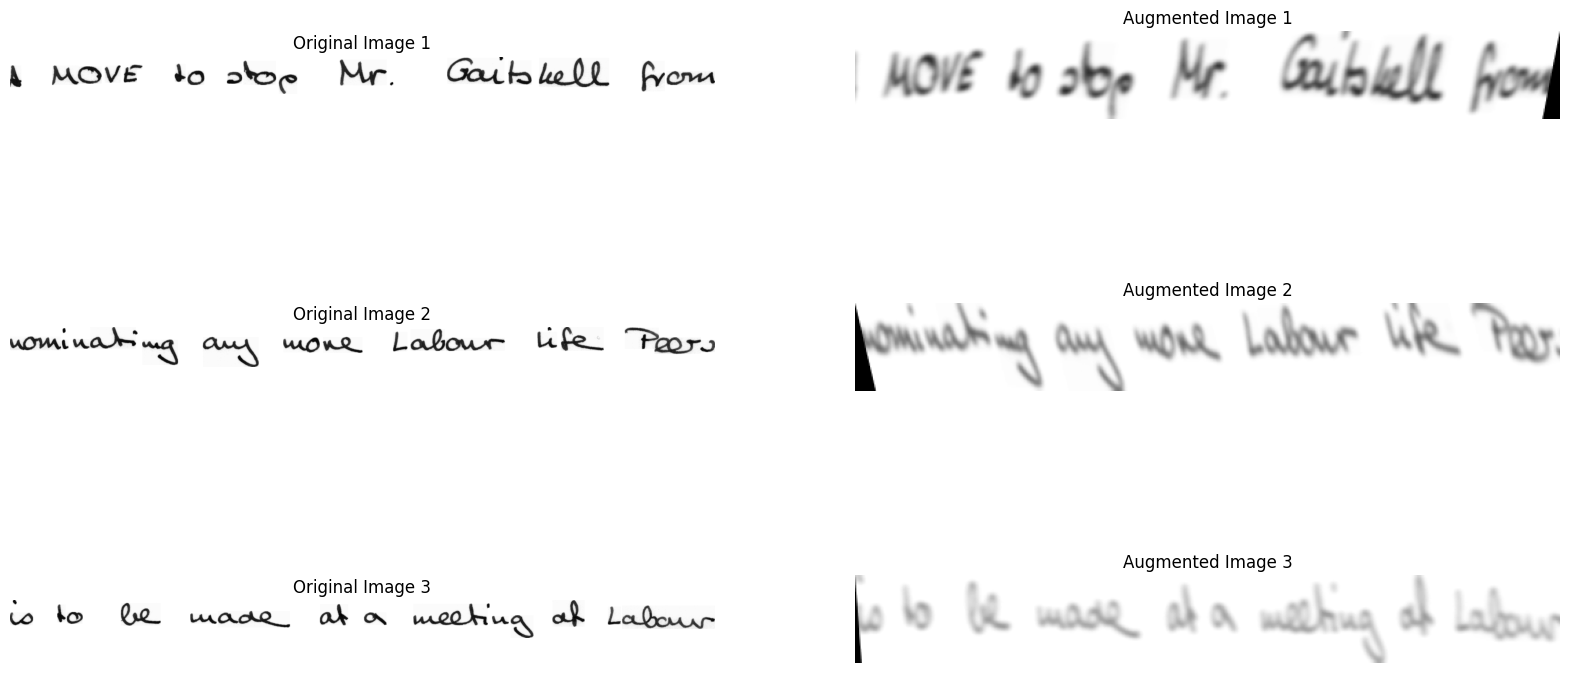

In [21]:
plt.figure(figsize=(20, 10))

for i in range(3):
    img_path = img_paths[i]
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    aug_img1 = preprocess1(img)
    aug_img = aug_img1.astype(np.float32) / 255.0
    plt.subplot(3, 2, i * 2 + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Original Image {i + 1}')
    plt.axis('off')

    plt.subplot(3, 2, i * 2 + 2)
    plt.imshow(aug_img, cmap='gray')
    plt.title(f'Augmented Image {i + 1}')
    plt.axis('off')

plt.show()

In [22]:
train_data, temp_data = train_test_split(data, test_size = 0.142, random_state = 42, shuffle = True)

In [23]:
valid_data, test_data = train_test_split(temp_data, test_size = 0.5, random_state = 42, shuffle = True)

In [24]:
print(train_data[0:2], valid_data[0:2], test_data[0:2])

                                                  path  \
4093  /kaggle/input/dataset/dataset/c06-000-s02-00.png   
2034  /kaggle/input/dataset/dataset/b01-027-s01-02.png   

                                           label  
4093                                MOST OF IT .  
2034  HAVE TAKEN THE HEADLINES IN THIS COUNTRY .                                                      path  \
8992   /kaggle/input/dataset/dataset/h02-024-s00-00.png   
13957  /kaggle/input/dataset/dataset/r06-076-s01-02.png   

                                               label  
8992   8 . THE SECOND PART OF OUR INTERIM REPORT WAS  
13957        LOVE HOUSE , THE MAD GRANDMOTHER OR THE                                                      path  \
6357  /kaggle/input/dataset/dataset/f07-019b-s00-03.png   
3608  /kaggle/input/dataset/dataset/c03-081d-s01-01.png   

                                               label  
6357             THAT AMAZING EPOCH OF GROSSNESS AND  
3608  MAKES HER FEW BRIEF SCENES EFFECTIV

In [25]:
train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)
test_data.reset_index(drop=True, inplace=True)

In [26]:
train_size = len(train_data)
valid_size = len(valid_data)
test_size = len(test_data)

In [27]:
train_size, valid_size, test_size

(12083, 1000, 1000)

In [28]:
img_aug_cnt=0

In [29]:
train_x = []

for index,row in train_data.iterrows():
    image = cv2.imread(row['path'], cv2.IMREAD_GRAYSCALE)
    
    t=image
    if random.randint(0, 10) in [1,2,3,4,5]:
        t= augment_image(t)
        img_aug_cnt=img_aug_cnt+1

    t = preprocess(t)
    t = t.astype('float32') / 255.0
    train_x.append(t)

In [30]:
valid_x = []

for index,row in valid_data.iterrows():
    image = cv2.imread(row['path'], cv2.IMREAD_GRAYSCALE)
    image = preprocess(image)
    image = image.astype('float32') / 255.0
    valid_x.append(image)

In [31]:
test_x = []

for index,row in test_data.iterrows():
    image = cv2.imread(row['path'], cv2.IMREAD_GRAYSCALE)
    image = preprocess(image)
    image = image.astype('float32') / 255.0
    test_x.append(image)

In [32]:
print('train:',len(train_x),'valid:',len(valid_x),'test:',len(test_x))

train: 12083 valid: 1000 test: 1000


In [33]:
np.asarray(train_x).shape

(12083, 512, 64)

In [34]:
train_x = np.array(train_x).reshape(-1, 512, 64, 1)
valid_x = np.array(valid_x).reshape(-1, 512, 64, 1)
test_x = np.array(test_x).reshape(-1, 512, 64, 1)

In [35]:
datagen = ImageDataGenerator(
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    rotation_range=20,
    fill_mode='nearest'
)

datagen.fit(train_x)

In [36]:
alphabets = u"ABCDEFGHIJKLMNOPQRSTUVWXYZ-,!?.' "
max_str_len = 95 # max length of input labels
num_of_characters = len(alphabets) + 1 # +1 for ctc pseudo blank
num_of_timestamps = 128 # max length of predicted labels


def label_to_num(label):
    label_num = []
    for ch in label:
        ind=alphabets.find(ch)
        if ind != -1:
            label_num.append(ind)
        else:
            label_num.append(0)
    return np.array(label_num)

def num_to_label(num):
    ret = ""
    for ch in num:
        if ch == -1:  # CTC Blank
            break
        else:
            ret+=alphabets[ch]
    return ret

In [37]:
train_y = np.ones([train_size,max_str_len]) * -1
train_label_len = np.zeros([train_size, 1])
train_input_len = np.ones([train_size, 1]) * (num_of_timestamps-2)
train_output = np.zeros([train_size])

for i,row in train_data.iterrows():
    train_label_len[i] = len(row['label'])
    train_y[i, 0:len(row['label'])]= label_to_num(row['label'])

In [38]:
valid_y = np.ones([valid_size, max_str_len]) * -1
valid_label_len = np.zeros([valid_size, 1])
valid_input_len = np.ones([valid_size, 1]) * (num_of_timestamps-2)
valid_output = np.zeros([valid_size])

for i,row in valid_data.iterrows():
    valid_label_len[i] = len(row['label'])
    valid_y[i, 0:len(row['label'])]= label_to_num(row['label'])

In [39]:
test_y = np.ones([test_size, max_str_len]) * -1
test_label_len = np.zeros([test_size, 1])
test_input_len = np.ones([test_size, 1]) * (num_of_timestamps-2)
test_output = np.zeros([test_size])

for i,row in test_data.iterrows():
    test_label_len[i] = len(row['label'])
    test_y[i, 0:len(row['label'])]= label_to_num(row['label'])

In [40]:
print('True label : ',train_data.loc[100, 'label'] , '\ntrain_y : ',train_y[100],'\ntrain_label_len : ',train_label_len[100], 
      '\ntrain_input_len : ', train_input_len[100])

True label :  THE DIRECTIONAL ANGLE OF THE 
train_y :  [19.  7.  4. 32.  3.  8. 17.  4.  2. 19.  8. 14. 13.  0. 11. 32.  0. 13.
  6. 11.  4. 32. 14.  5. 32. 19.  7.  4. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1.] 
train_label_len :  [28.] 
train_input_len :  [126.]


In [41]:
# Load MobileNetV2 pre-trained on ImageNet, excluding the top layers
mobilenet_v2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(512, 64, 3))

# Freeze the pre-trained layers to prevent them from updating during training
mobilenet_v2.trainable = False

for layer in mobilenet_v2.layers[-30:]:
    layer.trainable = True  # Fine-tune last 10 layers

/tmp/ipykernel_35/2188545552.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_v2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(512, 64, 3))
I0000 00:00:1747595745.354902      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747595745.355638      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [42]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Reshape, Lambda, BatchNormalization
from tensorflow.keras.layers import Bidirectional, LSTM
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
import tensorflow as tf

input_data = Input(shape=(512, 64, 1), name='input')
x = tf.keras.layers.Concatenate()([input_data, input_data, input_data])  # convert grayscale to RGB (3 channels)

resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(512, 64, 3))
resnet_base.trainable = False  # freeze all layers
for layer in resnet_base.layers[-10:]:
    layer.trainable = True  # fine-tune last 10 layers

x = resnet_base(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

# Reshape for RNN
x = Reshape(target_shape=(x.shape[1], x.shape[2]*x.shape[3]))(x)
x = Dense(256, activation='relu', kernel_initializer='he_normal')(x)
x = Bidirectional(LSTM(512, return_sequences=True, dropout=0.25))(x)
x = Bidirectional(LSTM(512, return_sequences=True, dropout=0.25))(x)
x = Dense(num_of_characters, kernel_initializer='he_normal')(x)
y_pred = Activation('softmax', name='softmax')(x)

# CTC loss
labels = Input(name='gtruth_labels', shape=[max_str_len], dtype='float32')
input_length = Input(name='input_length', shape=[1], dtype='int64')
label_length = Input(name='label_length', shape=[1], dtype='int64')

def ctc_lambda_func(args):
    y_pred, labels, input_length, label_length = args
    y_pred = y_pred[:, 2:, :]  # skip first timesteps
    return K.ctc_batch_cost(labels, y_pred, input_length, label_length)

ctc_loss = Lambda(ctc_lambda_func, output_shape=(1,), name='ctc')([y_pred, labels, input_length, label_length])
model_final = Model(inputs=[input_data, labels, input_length, label_length], outputs=ctc_loss)

# Compile
def dummy_loss(y_true, y_pred):
    return y_pred

model_final.compile(loss={'ctc': dummy_loss}, optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 512, 64, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 512, 64, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 512, 64, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512, 64, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max1 (MaxPooling2D)                  │ (None, 256, 32, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 256, 32, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256, 32, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256, 32, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max2 (MaxPooling2D)                  │ (None, 128, 16, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128, 16, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv2D)                       │ (None, 128, 16, 128)        │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128, 16, 128)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128, 16, 128)        │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv4 (Conv2D)                       │ (None, 128, 16, 128)        │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 128, 16, 128)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128, 16, 128)        │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max3 (MaxPooling2D)                  │ (None, 128, 8, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128, 8, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128, 8, 128)         │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 9,984,802 (38.09 MB)

 Trainable params: 9,983,842 (38.09 MB)

 Non-trainable params: 960 (3.75 KB)

In [43]:
@keras.utils.register_keras_serializable()

def ctc_lambda_func(args):
    y_pred, labels, input_length, label_length = args
    # the 2 is critical here since the first couple outputs of the RNN
    # tend to be garbage
    y_pred = y_pred[:, 2:, :]
    return tf.keras.backend.ctc_batch_cost(labels, y_pred, input_length, label_length)

In [44]:
labels = Input(name='gtruth_labels', shape=[max_str_len], dtype='float32')
input_length = Input(name='input_length', shape=[1], dtype='int64')
label_length = Input(name='label_length', shape=[1], dtype='int64')

ctc_loss = Lambda(ctc_lambda_func, output_shape=(1,), name='ctc')([y_pred, labels, input_length, label_length])
model_final = Model(inputs=[input_data, labels, input_length, label_length], outputs=ctc_loss)
model_final.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)        │ (None, 512, 64, 1)     │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1 (Conv2D)            │ (None, 512, 64, 32)    │            320 │ input[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 512, 64, 32)    │              0 │ conv1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 512, 64, 32)    │            128 │ activation[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max1 (MaxPooling2D)       │ (None, 256, 32, 32)    │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2 (Conv2D)            │ (None, 256, 32, 64)    │         18,496 │ max1[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 256, 32, 64)    │              0 │ conv2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 256, 32, 64)    │            256 │ activation_1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max2 (MaxPooling2D)       │ (None, 128, 16, 64)    │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 128, 16, 64)    │              0 │ max2[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3 (Conv2D)            │ (None, 128, 16, 128)   │         73,856 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 128, 16, 128)   │              0 │ conv3[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 128, 16, 128)   │            512 │ activation_2[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv4 (Conv2D)            │ (None, 128, 16, 128)   │        147,584 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 128, 16, 128)   │              0 │ conv4[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 128, 16, 128)   │            512 │ activation_3[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max3 (MaxPooling2D)       │ (None, 128, 8, 128)    │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)  

 Total params: 9,984,802 (38.09 MB)

 Trainable params: 9,983,842 (38.09 MB)

 Non-trainable params: 960 (3.75 KB)

In [45]:
# Define the named dummy loss function
def dummy_loss(y_true, y_pred):
    return y_pred

In [48]:
optimizer = Adam(learning_rate=0.0001)
model_final.compile(loss={'ctc': dummy_loss}, optimizer=optimizer)

In [47]:
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1).numpy()

checkpoint = ModelCheckpoint('model.keras', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1, min_lr=0.0001)
lr_scheduler = LearningRateScheduler(scheduler)

callbacks = [checkpoint, early_stopping, reduce_lr, lr_scheduler]

In [51]:
 import os
os.environ['TF_ENABLE_LAYOUT_OPTIMIZATION'] = '1'

In [ ]:
history = model_final.fit(
    x=[train_x, train_y, train_input_len, train_label_len],
    y=train_output, 
    validation_data=([valid_x, valid_y, valid_input_len, valid_label_len], valid_output),
    epochs=100, batch_size=64, verbose=1,
    callbacks=callbacks
)

Epoch 1/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 111.1975
Epoch 1: val_loss improved from inf to 106.87414, saving model to model.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 282s 1s/step - loss: 111.1665 - val_loss: 106.8741 - learning_rate: 1.0000e-04
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 99.0291
Epoch 2: val_loss improved from 106.87414 to 83.88804, saving model to model.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - loss: 99.0046 - val_loss: 83.8880 - learning_rate: 1.0000e-04
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 82.3061
Epoch 3: val_loss improved from 83.88804 to 71.09766, saving model to model.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - loss: 82.2932 - val_loss: 71.0977 - learning_rate: 1.0000e-04
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 73.2708
Epoch 4: val_loss improved from 71.09766 to 60.47235, saving model to model.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - loss: 73.2596 - val_loss: 60.4724 - le

In [57]:
model_final.save('/kaggle/working/model_final.keras', overwrite=True)
model_final.save('/kaggle/working/model_final.h5', overwrite=True)
model.save('/kaggle/working/model.keras', overwrite=True)
model.save('/kaggle/working/model.h5', overwrite=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


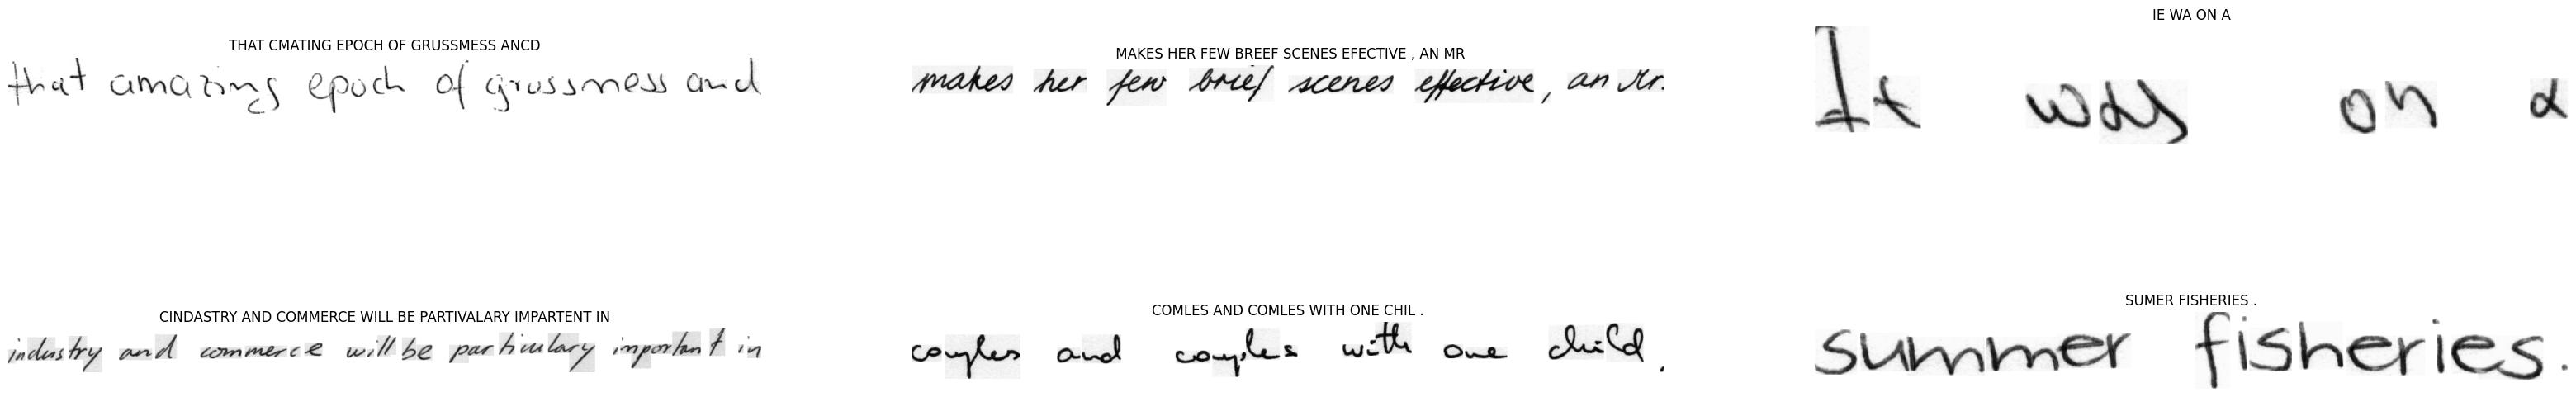

In [58]:
plt.figure(figsize=(40, 25))
for i in range(0,6):
    ax = plt.subplot(2, 3, i+1)
    img_dir = test_data.loc[i, 'path']
    image = cv2.imread(img_dir, cv2.IMREAD_GRAYSCALE)
    plt.imshow(image, cmap='gray')
    
    image = preprocess(image)
    image = image.astype('float32')/255.0
    pred = model.predict(image.reshape(1, 512, 64, 1))
    decoded = tf.keras.backend.get_value(tf.keras.backend.ctc_decode(pred, input_length=np.ones(pred.shape[0])*pred.shape[1], 
                                       greedy=True)[0][0])
    plt.title(num_to_label(decoded[0]), fontsize=12)
    plt.axis('off')
    
plt.subplots_adjust(wspace=0.2, hspace=-0.8)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

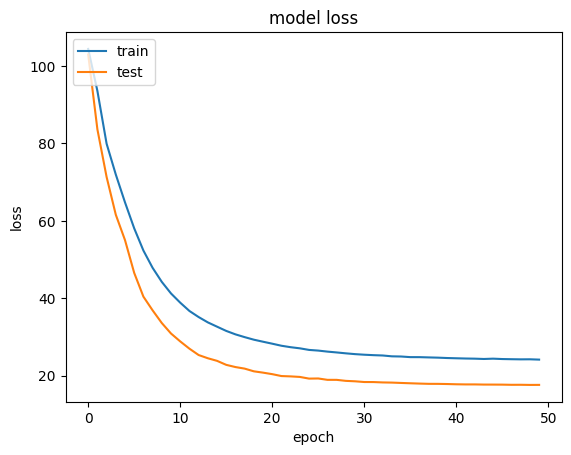

In [59]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [60]:
model.save_weights('model.weights.h5')
model_final.save_weights('model_final.weights.h5')

In [62]:
preds = model.predict(test_x)
decoded = tf.keras.backend.get_value(tf.keras.backend.ctc_decode(preds, input_length=np.ones(preds.shape[0])*preds.shape[1], 
                                   greedy=True)[0][0])

prediction = []
for i in range(test_size):
    prediction.append(num_to_label(decoded[i]))

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 255ms/step


In [63]:
y_true = test_data.loc[0 : test_size, 'label']


def calculate_accuracy(y_true, y_pred):
    total_words = 0
    correct_words = 0
    total_char = 0
    correct_char = 0

    for true_sentence, pred_sentence in zip(y_true, y_pred):
        true_words = true_sentence.split()
        pred_words = pred_sentence.split()
        

        total_words += len(true_words)

        # Calculate word accuracy
        for true_word, pred_word in zip(true_words, pred_words):
            if true_word == pred_word:
                correct_words += 1
            total_char += len(true_word)
    
            for j in range(min(len(true_word), len(pred_word))):
                if true_word[j] == pred_word[j]:
                    correct_char += 1

    word_accuracy = correct_words / total_words if total_words > 0 else 0
    character_accuracy = correct_char/ total_char if total_char> 0 else 0

    return word_accuracy, character_accuracy


word_accuracy, character_accuracy = calculate_accuracy(y_true, prediction)
print("Word Accuracy:", word_accuracy)
print("Character Accuracy:", character_accuracy)

Word Accuracy: 0.5209795430789906
Character Accuracy: 0.6828664969079665


In [64]:
from tensorflow.keras.models import load_model

loaded_model = load_model('/kaggle/working/model.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step


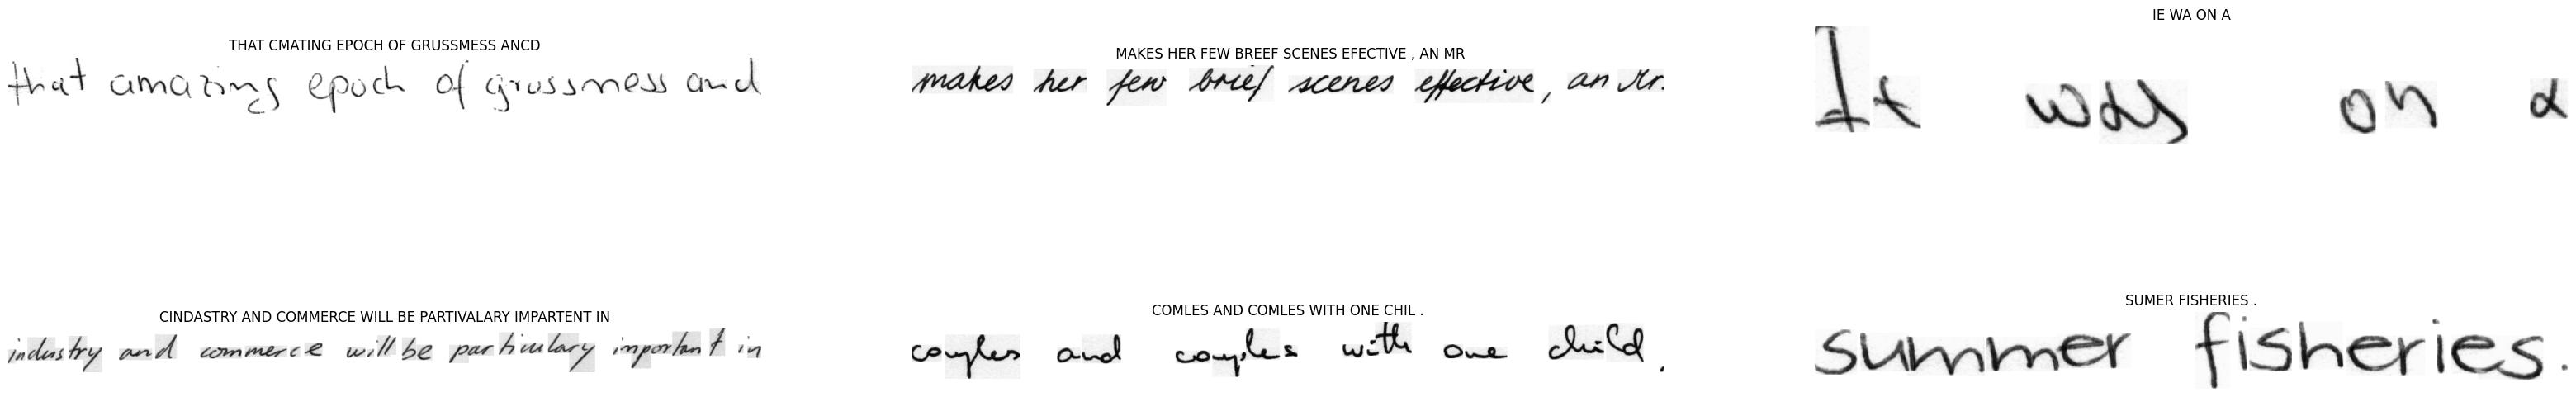

In [65]:
plt.figure(figsize=(40, 25))
for i in range(0,6):
    ax = plt.subplot(2, 3, i+1)
    img_dir = test_data.loc[i, 'path']
    image = cv2.imread(img_dir, cv2.IMREAD_GRAYSCALE)
    plt.imshow(image, cmap='gray')
    
    image = preprocess(image)
    image = image.astype('float32')/255.
    pred = loaded_model.predict(image.reshape(1, 512, 64, 1))
    decoded = tf.keras.backend.get_value(tf.keras.backend.ctc_decode(pred, input_length=np.ones(pred.shape[0])*pred.shape[1], 
                                       greedy=True)[0][0])
    plt.title(num_to_label(decoded[0]), fontsize=12)
    plt.axis('off')
    
plt.subplots_adjust(wspace=0.2, hspace=-0.8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
A HANDURITTEN DOCUMNERNTS AND HISTORICAL ARCHIVES .


(-0.5, 2045.5, 154.5, -0.5)

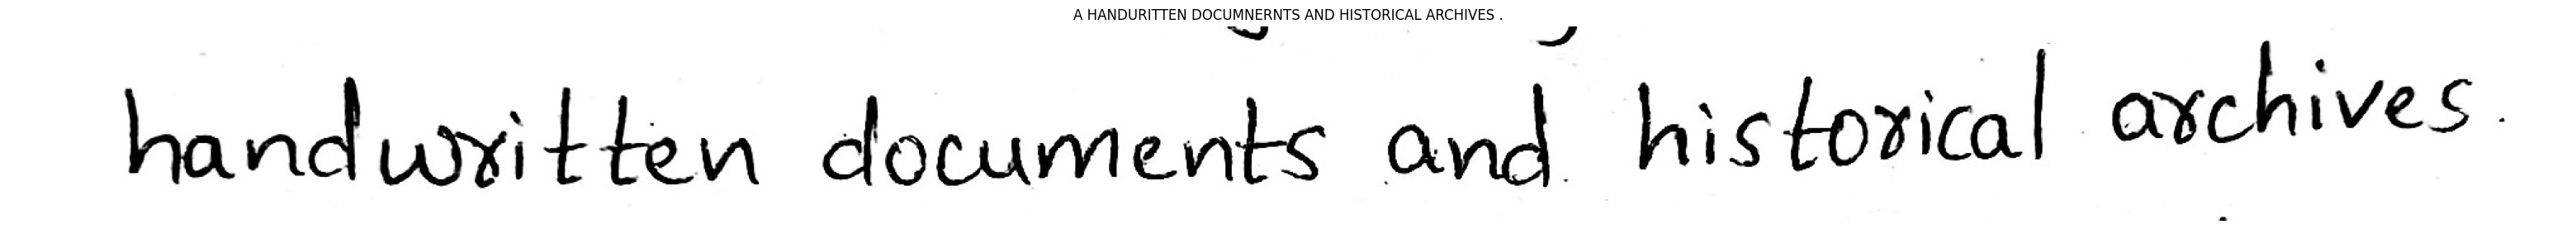

In [66]:
plt.figure(figsize=(40, 25))

# ax = plt.subplot(2, 3, i+1)
img_dir = '/kaggle/input/test-images/img.jpg'
image = cv2.imread(img_dir, cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')

image = preprocess(image)
image = image.astype('float32')/255.
pred = loaded_model.predict(image.reshape(1, 512, 64, 1))
decoded = tf.keras.backend.get_value(tf.keras.backend.ctc_decode(pred, input_length=np.ones(pred.shape[0])*pred.shape[1], 
                                   greedy=True)[0][0])
print(num_to_label(decoded[0]))
plt.title(num_to_label(decoded[0]), fontsize=12)
plt.axis('off')
    